## Введение
<b>
В рамках исследования закономерностей поведения рынка акций Московской биржи проведена сегментация акций с использованием алгоритмов кластеризации. Для выявления групп использованы такие характеристики инструмента как ликвидность, доходность и волатильность акции.
  
План исследования:
1. Загрузка данных.
2. Подготовка и очистка данных.
3. Подготовка признаков для последующего применения алгоритмов кластеризации.
4. Разведочный анализ. 
5. Применение моделей (метод k-средних, агломерационный кластеринг, DBSCAN).
6. Оценка качества моделей и их применимости к рассматриваемому набору данных.
7. Выбор наиболее релевантной модели и интерпретация результатов.<b>

## 1. Загрузка данных

In [57]:
import warnings

import numpy as np
import pandas as pd

import requests

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from yellowbrick.cluster import KElbowVisualizer

import scipy.cluster.hierarchy as sch

warnings.filterwarnings("ignore")

Для получения информации о торговых сессиях российского рынка акций, проводимых в период с 2022-2026 гг на Московской бирже, используется Информационно-статистический сервер Московской Биржи (ИСС).

ИСС позволяет получать данные о российских акциях, торгующихся на Московской бирже. Для исследования необходимы исторические данные об акциях, торгующихся в основном режиме торгов.

In [3]:
stock_url = 'https://iss.moex.com/iss/engines/stock/markets/shares/securities.json'

stock_desc_response = requests.get(stock_url).json()

columns = stock_desc_response['securities']['columns']
data = stock_desc_response['securities']['data']

stock_desc_data = pd.DataFrame(data, columns=columns)

In [4]:
stock_desc_data = stock_desc_data[(stock_desc_data['BOARDID'] == 'TQBR') & (stock_desc_data['STATUS'] == 'A')] # TQBR - основной режим торогов
stock_desc_data.head()

,SECID,BOARDID,SHORTNAME,PREVPRICE,LOTSIZE,FACEVALUE,STATUS,BOARDNAME,DECIMALS,SECNAME,...,PREVDATE,ISSUESIZE,ISIN,LATNAME,REGNUMBER,PREVLEGALCLOSEPRICE,CURRENCYID,SECTYPE,LISTLEVEL,SETTLEDATE
257,ABIO,TQBR,iАРТГЕН ао,47.740,10,0.10,A,Т+: Акции и ДР - безадрес.,2,"ПАО ""Артген""",...,2026-05-29,92645451,RU000A0JNAB6,ARTGEN ao,1-01-08902-A,48.34,SUR,1,2,2026-06-02
258,ABRD,TQBR,АбрауДюрсо,137.200,10,1.00,A,Т+: Акции и ДР - безадрес.,1,Абрау-Дюрсо ПАО ао,...,2026-05-29,108889117,RU000A0JS5T7,Abrau-Durso ao,1-02-12500-A,136.20,SUR,1,3,2026-06-02
259,AFKS,TQBR,Система ао,12.059,100,0.09,A,Т+: Акции и ДР - безадрес.,3,"АФК ""Система"" ПАО ао",...,2026-05-29,9650000000,RU000A0DQZE3,AFK Sistema,1-05-01669-A,12.06,SUR,1,1,2026-06-02
260,AFLT,TQBR,Аэрофлот,48.330,10,1.00,A,Т+: Акции и ДР - безадрес.,2,Аэрофлот-росс.авиалин(ПАО)ао,...,2026-05-29,3975771215,RU0009062285,Aeroflot,1-01-00010-A,48.32,SUR,1,1,2026-06-02
261,AKRN,TQBR,Акрон,18322.000,1,5.00,A,Т+: Акции и ДР - безадрес.,0,Акрон ПАО ао,...,2026-05-29,36757156,RU0009028674,Acron,1-03-00207-A,18364.00,SUR,1,2,2026-06-02


В поле "SECID" содержится торговый код ценной бумаги. Необходимо загрузить результы завершенных торговых сессий в период с 2022-2026 гг.

In [5]:
tickers = stock_desc_data['SECID'].unique()

ИСС ограничивает размер выдачи, поэтому каждый год загружается отдельно, в последствии соединяется в общий датафрейм "all_tickets_history".

In [8]:
# 2022-2023 гг

history = []

for ticker in tickers:
    url_history = f'https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json'

    params = {
    'from': '2022-05-01',
    'till': '2023-05-01',
    'interval': 24
    }
    response_history = requests.get(url_history, params=params).json()

    columns = response_history['candles']['columns']
    data = response_history['candles']['data']
    ticker_df = pd.DataFrame(data, columns=columns)
    ticker_df['ticker'] = ticker

    history.append(ticker_df)

history_22_23 = pd.concat(history, ignore_index=True)

In [9]:
history_22_23.head()

,open,close,high,low,value,volume,begin,end,ticker
0,74.04,73.70,75.46,73.02,16026487.4,216230,2022-05-04 00:00:00,2022-05-04 23:59:59,ABIO
1,73.40,71.28,73.92,71.00,22712772.0,314160,2022-05-05 00:00:00,2022-05-05 23:59:59,ABIO
2,72.00,69.32,72.00,68.60,14109172.2,201850,2022-05-06 00:00:00,2022-05-06 23:59:59,ABIO
3,69.40,68.68,70.90,68.00,12527452.6,182020,2022-05-11 00:00:00,2022-05-11 23:59:59,ABIO
4,68.24,66.00,69.30,65.52,16553769.8,247710,2022-05-12 00:00:00,2022-05-12 23:59:59,ABIO


In [10]:
# 2023-2024 гг

history = []

for ticker in tickers:
    url_history = f'https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json'

    params = {
    'from': '2023-05-01',
    'till': '2024-05-01',
    'interval': 24
    }
    response_history = requests.get(url_history, params=params).json()

    columns = response_history['candles']['columns']
    data = response_history['candles']['data']
    ticker_df = pd.DataFrame(data, columns=columns)
    ticker_df['ticker'] = ticker

    history.append(ticker_df)

history_23_24 = pd.concat(history, ignore_index=True)

In [11]:
history_23_24.head()

,open,close,high,low,value,volume,begin,end,ticker
0,119.8,106.18,120.28,102.00,395853707.8,3559780,2023-05-02 00:00:00,2023-05-02 23:59:59,ABIO
1,106.0,100.68,112.56,97.24,453788537.0,4364690,2023-05-03 00:00:00,2023-05-03 23:59:59,ABIO
2,100.7,103.28,106.50,100.50,184708685.8,1771610,2023-05-04 00:00:00,2023-05-04 23:59:59,ABIO
3,103.9,101.04,105.00,100.86,64093261.2,624640,2023-05-05 00:00:00,2023-05-05 23:59:59,ABIO
4,101.9,101.50,103.38,101.26,26432398.2,258910,2023-05-08 00:00:00,2023-05-08 23:59:59,ABIO


In [12]:
# 2024-2025 гг

history = []

for ticker in tickers:
    url_history = f'https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json'

    params = {
    'from': '2024-05-01',
    'till': '2025-05-01',
    'interval': 24
    }
    response_history = requests.get(url_history, params=params).json()

    columns = response_history['candles']['columns']
    data = response_history['candles']['data']
    ticker_df = pd.DataFrame(data, columns=columns)
    ticker_df['ticker'] = ticker

    history.append(ticker_df)

history_24_25 = pd.concat(history, ignore_index=True)

In [13]:
history_24_25.head()

,open,close,high,low,value,volume,begin,end,ticker
0,112.44,111.52,113.62,111.00,57281797.4,510820,2024-05-02 00:00:00,2024-05-02 23:59:59,ABIO
1,113.48,113.00,118.00,112.30,169385177.6,1476370,2024-05-03 00:00:00,2024-05-03 23:59:59,ABIO
2,113.12,111.20,113.28,110.52,62720329.2,561860,2024-05-06 00:00:00,2024-05-06 23:59:59,ABIO
3,111.50,111.50,112.94,111.10,29983717.8,268440,2024-05-07 00:00:00,2024-05-07 23:59:59,ABIO
4,111.72,110.58,112.14,110.10,27068490.2,244300,2024-05-08 00:00:00,2024-05-08 23:59:59,ABIO


In [14]:
# 2025-2026 гг

history = []

for ticker in tickers:
    url_history = f'https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json'

    params = {
    'from': '2025-05-01',
    'till': '2026-05-01',
    'interval': 24
    }
    response_history = requests.get(url_history, params=params).json()

    columns = response_history['candles']['columns']
    data = response_history['candles']['data']
    ticker_df = pd.DataFrame(data, columns=columns)
    ticker_df['ticker'] = ticker

    history.append(ticker_df)

history_25_26 = pd.concat(history, ignore_index=True)

In [15]:
history_25_26.head()

,open,close,high,low,value,volume,begin,end,ticker
0,82.70,80.52,82.70,80.28,11163430.6,137630,2025-05-02 00:00:00,2025-05-02 23:59:55,ABIO
1,80.52,80.98,81.22,80.30,1868773.0,23130,2025-05-03 00:00:00,2025-05-03 23:59:57,ABIO
2,80.72,81.40,81.44,80.72,598468.8,7370,2025-05-04 00:00:00,2025-05-04 23:59:57,ABIO
3,81.42,80.80,82.10,79.50,11713870.0,144960,2025-05-05 00:00:00,2025-05-05 23:59:56,ABIO
4,80.36,82.34,83.00,80.36,14048167.0,170860,2025-05-06 00:00:00,2025-05-06 23:59:59,ABIO


In [16]:
all_tickets_history = pd.concat([history_22_23, history_23_24, history_24_25, history_25_26], ignore_index=True)
all_tickets_history

,open,close,high,low,value,volume,begin,end,ticker
0,74.04,73.70,75.46,73.02,16026487.4,216230,2022-05-04 00:00:00,2022-05-04 23:59:59,ABIO
1,73.40,71.28,73.92,71.00,22712772.0,314160,2022-05-05 00:00:00,2022-05-05 23:59:59,ABIO
2,72.00,69.32,72.00,68.60,14109172.2,201850,2022-05-06 00:00:00,2022-05-06 23:59:59,ABIO
3,69.40,68.68,70.90,68.00,12527452.6,182020,2022-05-11 00:00:00,2022-05-11 23:59:59,ABIO
4,68.24,66.00,69.30,65.52,16553769.8,247710,2022-05-12 00:00:00,2022-05-12 23:59:59,ABIO
...,...,...,...,...,...,...,...,...,...
252866,6.66,6.65,6.72,6.58,139380.0,21000,2026-04-27 00:00:00,2026-04-27 23:59:58,ZVEZ
252867,6.60,6.50,6.68,6.50,717640.0,110000,2026-04-28 00:00:00,2026-04-28 23:59:59,ZVEZ
252868,6.58,6.51,6.59,6.50,163280.0,25000,2026-04-29 00:00:00,2026-04-29 23:59:59,ZVEZ
252869,6.48,6.42,6.52,6.38,220240.0,34000,2026-04-30 00:00:00,2026-04-30 23:59:58,ZVEZ


Описание полей датафрейма "all_tickets_history":  

**open** - цена открытия  
**close** - цена закрытия  
**high** - максимальная цена за день  
**low** - минимальная цена за день  
**value** - денежный объём торгов  
**volume** - количество купленных/проданных бумаг  
**begin** -	начало торгового дня  
**end** -	конец торгового дня  
**ticker** - тикер акции 

Для последующей интерпретации результатов необходимы данные о принадлежность компании к сектору экономики и характеристика ее деятельности. Данные содержатся в excel-файле dictionary.xlsx.

In [17]:
dict = pd.read_excel('dictionary.xlsx')
dict.head()

,ticker,isin,sector,description
0,ABIO,RU000A0JNAB6,Медицина и биотехнологии,"Артген биотех - биотехнологическая компания, ц..."
1,ABRD,RU000A0JS5T7,Потребительский сектор,Завод шампанских вин «Абрау-Дюрсо» — крупнейши...
2,AFKS,RU000A0DQZE3,Потребительский сектор,АФК «Система» является одной из самых крупных ...
3,AFLT,RU0009062285,Машиностроение и транспорт,"Группа «Аэрофлот» — авиакомпания, которая осущ..."
4,AKRN,RU0009028674,Сырьевая промышленность,"Группа ""Акрон"" входит в число ведущих мировых ..."


## 2. Подготовка и очистка данных.

Для исследования понадобятся значения полей ticker, begin, close, value.  
Исторические данные указанных полей сохранены в датафреме "history".

In [18]:
history = all_tickets_history[['ticker', 'begin', 'close', 'value']]

In [19]:
history.sort_values(['ticker', 'begin'])

,ticker,begin,close,value
0,ABIO,2022-05-04 00:00:00,73.70,16026487.4
1,ABIO,2022-05-05 00:00:00,71.28,22712772.0
2,ABIO,2022-05-06 00:00:00,69.32,14109172.2
3,ABIO,2022-05-11 00:00:00,68.68,12527452.6
4,ABIO,2022-05-12 00:00:00,66.00,16553769.8
...,...,...,...,...
252866,ZVEZ,2026-04-27 00:00:00,6.65,139380.0
252867,ZVEZ,2026-04-28 00:00:00,6.50,717640.0
252868,ZVEZ,2026-04-29 00:00:00,6.51,163280.0
252869,ZVEZ,2026-04-30 00:00:00,6.42,220240.0


In [20]:
history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252871 entries, 0 to 252870
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ticker  252871 non-null  object 
 1   begin   252871 non-null  object 
 2   close   252871 non-null  float64
 3   value   252871 non-null  float64
dtypes: float64(2), object(2)
memory usage: 7.7+ MB


In [21]:
history['begin'] = pd.to_datetime(history['begin']) # begin содержит дату начала торогов, изменяем тип даттых на дату и время 

In [22]:
history.describe()

,begin,close,value
count,252871,252871.000000,2.528710e+05
mean,2024-06-28 19:10:17.565478144,1462.841767,3.532114e+08
min,2022-05-04 00:00:00,0.002110,1.728000e+02
25%,2023-06-28 00:00:00,8.400000,8.471435e+05
50%,2024-07-30 00:00:00,88.960000,7.762410e+06
75%,2025-07-17 00:00:00,595.000000,1.117805e+08
max,2026-05-01 00:00:00,64000.000000,8.798259e+10
std,NaN,4898.114532,1.492528e+09


In [23]:
history_count = history.groupby('ticker').count()
history_count[history_count['begin'] < 60]

,begin,close,value
ticker,,,
BTBR,10,10,10
GAZC,2,2,2
GAZS,2,2,2
GAZT,2,2,2


Исключаем акциий, у которых было менее 60 торговых сессий.

In [24]:
history = history[
(history['ticker'] != 'BTBR') &
(history['ticker'] != 'GAZC') &
(history['ticker'] != 'GAZS') &
(history['ticker'] != 'GAZT') ]

In [25]:
history['ticker'].nunique()

254

При построении модели будут использованы данные по 254 акциям.

## 3. Подготовка признаков для последующего применения алгоритмов кластеризации.

Для каждой акции необходимо найти среднюю доходность, ликвидность и волатильность за период.

Добавлено поле **"return"** которое содержит процентное изменение цены акций по сравнению с предыдущим торговым днем по цене закрытия. Из которого будут рассчитаны средняя волатильность и средняя доходность.

In [26]:
history['return'] = (history.groupby('ticker')['close'].pct_change())

**Доходность акций** - это процентный показатель, который отражает, сколько прибыли (или убытка) принес актив за определенный период времени.

**Волатильность** - это показатель изменчивости цены актива, отражающий, как сильно и быстро меняется его стоимость за определенный промежуток времени.

**Ликвидность** - это способность акции быть быстро проданной. Денежный эквивалент проданных за торговую сессию акций. Высокий оборот свидетельствует о о постоянном интересе к инструменту.

In [27]:
history_agg = history.groupby('ticker').agg({'return': ['mean', 'std'], 'value': 'mean'}).reset_index()

In [28]:
history_agg.columns = ['ticker', 'mean_return', 'volatility', 'mean_value']

Описание полей датафрейма "history_agg":

**ticker** - тикер акции  
**mean_return** - средняя дневная доходность за период, показывает средний темп изменения цены акции  
**volatility** - стандартное отклонение дневной доходности за период, показывает, насколько сильно колеблется цена акции  
**mean_value** - средний дневной объем торгов, показывает, насколько активно торгуется акция  

## 4. Разведочный анализ.

In [29]:
history_agg.describe()

,mean_return,volatility,mean_value
count,254.000000,254.000000,2.540000e+02
mean,0.000580,0.027503,3.427215e+08
std,0.000915,0.008245,9.832589e+08
min,-0.002187,0.009686,4.753151e+05
25%,0.000048,0.021088,3.097849e+06
50%,0.000595,0.026139,2.869283e+07
75%,0.001188,0.033800,2.173292e+08
max,0.002716,0.057207,9.797476e+09


Распределение значений средней дневной доходности.

<Axes: ylabel='mean_return'>

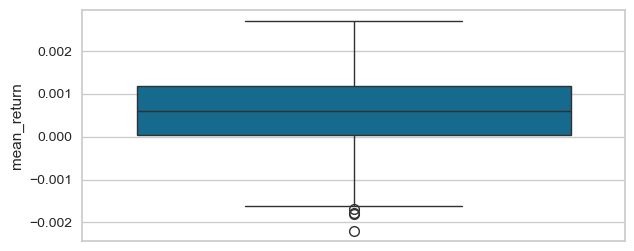

In [30]:
plt.figure(figsize=(7, 3))
sns.boxplot(history_agg['mean_return'])

Распределение значений средней волатильности.

<Axes: ylabel='volatility'>

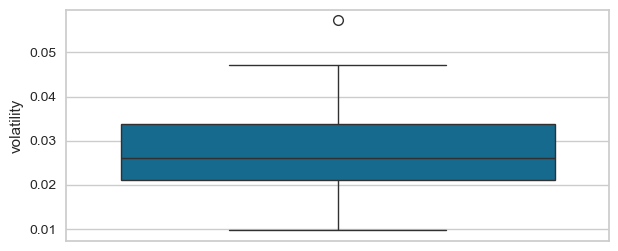

In [31]:
plt.figure(figsize=(7, 3))
sns.boxplot(history_agg['volatility'])

Распределение значений среднего объема торогов.

<Axes: ylabel='mean_value'>

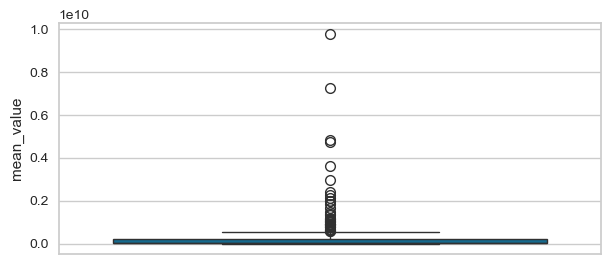

In [32]:
plt.figure(figsize=(7, 3))
sns.boxplot(history_agg['mean_value'])

array([[<Axes: title={'center': 'mean_return'}>,
        <Axes: title={'center': 'volatility'}>],
       [<Axes: title={'center': 'mean_value'}>, <Axes: >]], dtype=object)

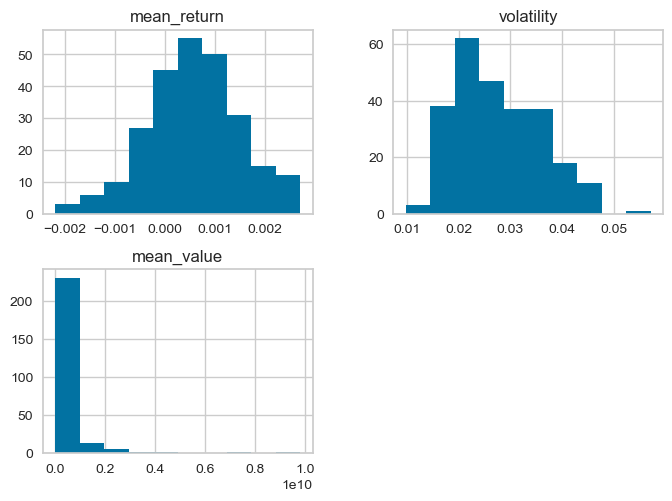

In [33]:
history_agg[['mean_return', 'volatility', 'mean_value']].hist()

Значения **средней дневной доходности** распределены нормально.  
Самая наименьшая средняя дневная доходность составляет -0,2%. Отрицательные средние дневные доходности свидетельствуют о том, что у акции преобладают падения цены или падения были сильнее или чаще встречались. График изменения цены такой акции будет выглядеть следующим образом.

In [34]:
history_agg[(history_agg['mean_return'] == history_agg['mean_return'].min())]

,ticker,mean_return,volatility,mean_value
33,DIAS,-0.002187,0.017721,7.731363e+07


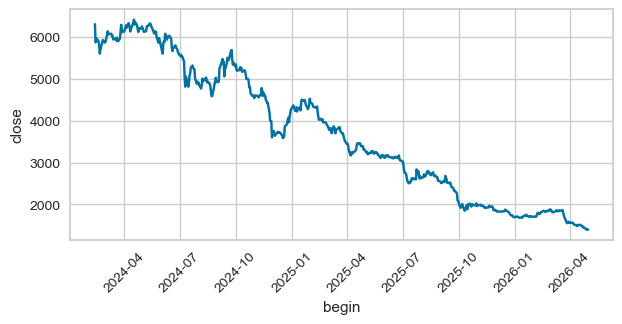

In [35]:
plt.figure(figsize=(7, 3))

sns.lineplot(data = history[history['ticker'] == 'DIAS'], x = 'begin', y ='close')

plt.xticks(rotation=45)

plt.show()

Высокая положительная средняя дневная доходность будет у акций, которые чаще прирастали относительно предыдущего дня или изменения в сторону роста были сильнее. График изменения цены такой акции будет выглядеть следующим образом.

In [36]:
history_agg[(history_agg['mean_return'] == history_agg['mean_return'].max())]

,ticker,mean_return,volatility,mean_value
98,LPSB,0.002716,0.045239,1.018289e+07


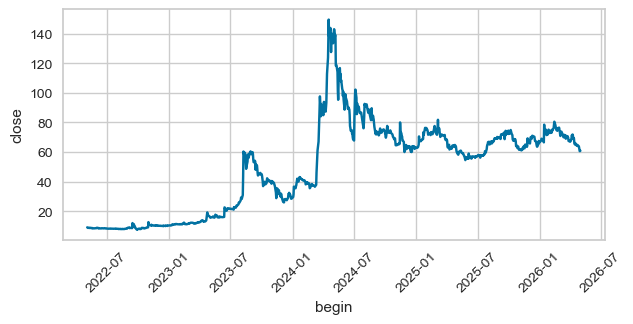

In [37]:
plt.figure(figsize=(7, 3))

sns.lineplot(data = history[history['ticker'] == 'LPSB'], x = 'begin', y ='close')

plt.xticks(rotation=45)

plt.show()

Медианное значение средней дневной доходности составляет 0,06%. Это значит, что большинство акции понемногу ежедневно прирастают, невысокое ежедневное изменение цены характерно для рынка акций.

Значения средней **волатильности** акций распределены асимметрично, выраженно смещены вправо, большинство акций обладают низкой волатильностью. Медианное значение составляет 2,6%. Встречаются акции с очень высокой волатильностью, например, акция GTRK, стоимость которой резко выросла в 2023 г. Волатильность напрямую связана с риском: чем выше изменение цены, тем выше риск и неопределенность для инвестора.

In [38]:
history_agg[(history_agg['volatility'] == history_agg['volatility'].max())]

,ticker,mean_return,volatility,mean_value
58,GTRK,0.002323,0.057207,2.214247e+08


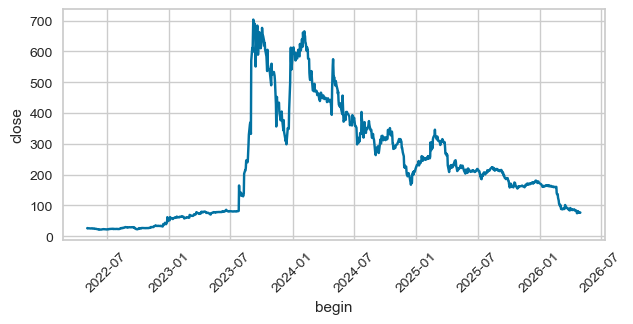

In [39]:
plt.figure(figsize=(7, 3))

sns.lineplot(data = history[history['ticker'] == 'GTRK'], x = 'begin', y ='close')

plt.xticks(rotation=45)

plt.show()

Распределение значений **ликвидности** смещено вправо. Преобладают акции с низким объем торгов, однако, в выборке также присутствуют акции с высокой ликвидностью - это акции крупнейших, надежных и финансово устойчивых компаний.

10 акций с самой высокой ликвидностью:

In [40]:
history_agg.sort_values('mean_value', ascending=False).head(10)

,ticker,mean_return,volatility,mean_value
184,SBER,0.000993,0.016011,9.797476e+09
51,GAZP,-0.000332,0.022818,7.234294e+09
96,LKOH,0.000265,0.016614,4.814152e+09
202,T,0.000490,0.023134,4.752630e+09
240,VTBR,0.000171,0.021611,3.632605e+09
246,YDEX,0.000113,0.017757,2.983621e+09
145,NVTK,0.000323,0.020773,2.410630e+09
170,ROSN,0.000224,0.017923,2.247366e+09
244,X5,-0.000291,0.016360,2.132616e+09
57,GMKN,-0.000281,0.018825,1.997092e+09


Для того, чтобы снизить влияние экстремально высоких показателей ликвидности на будущую модель, а также приблизить распределение средних значений ликвидности к нормальному, необходимо провести логарифмизацию признака mean_value.

In [41]:
history_agg['mean_value_log'] = np.log1p(history_agg['mean_value'])

<Axes: >

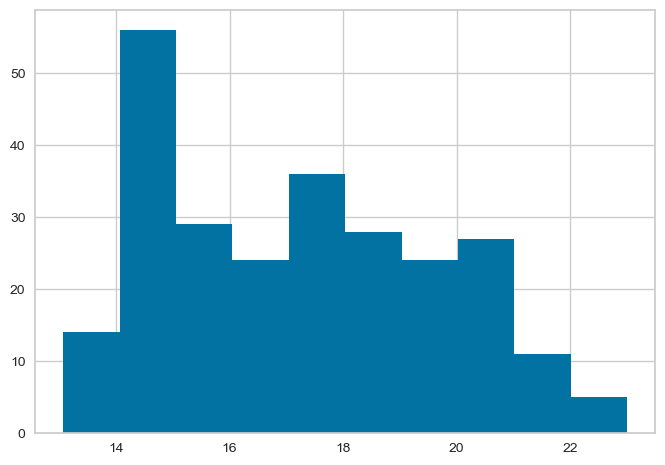

In [42]:
history_agg['mean_value_log'].hist()

In [43]:
history_agg.describe()

,mean_return,volatility,mean_value,mean_value_log
count,254.000000,254.000000,2.540000e+02,254.000000
mean,0.000580,0.027503,3.427215e+08,17.226402
std,0.000915,0.008245,9.832589e+08,2.407306
min,-0.002187,0.009686,4.753151e+05,13.071735
25%,0.000048,0.021088,3.097849e+06,14.946219
50%,0.000595,0.026139,2.869283e+07,17.172041
75%,0.001188,0.033800,2.173292e+08,19.196377
max,0.002716,0.057207,9.797476e+09,23.005391


Перед применением моделей кластеризации признаки акций необходимо привести к единому масштабу, применить **стандартизацию**, уменьшив тем самым влияние признака ликвидности, абсолютные значения которого значительно выше значений двух других признаков, а значит, при построении моделей будут сильно влиять на вычисления расстояний между объектами.

In [44]:
X = history_agg[['mean_return', 'volatility', 'mean_value_log']]

X = StandardScaler().fit_transform(X)

В результате каждое значение признака отражает степень отклонения наблюдения от среднего уровня признака.

## 5. Применение моделей (метод k-средних, агломареционного кластеринга, DBSCAN).

**Метод k-средних**

Для метода k-средних необходимо подобрать оптимальное количество кластеров, используя метод локтя.

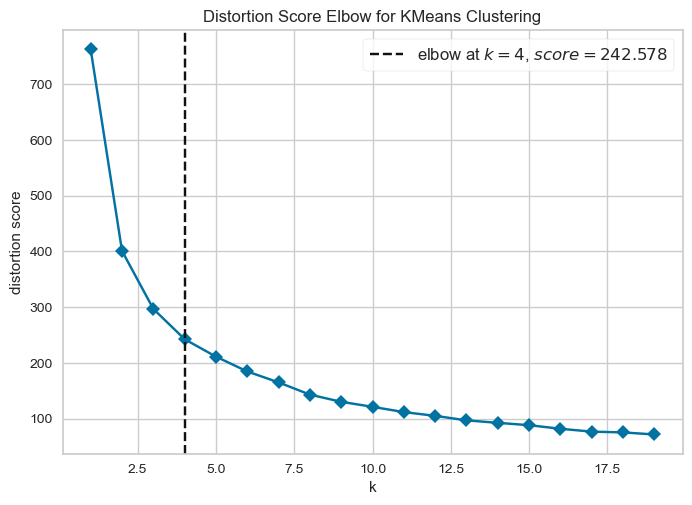

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [45]:
model = KMeans(
    random_state=42,
    n_init=10
)

visualizer = KElbowVisualizer(
    model,
    k=(1,20),
    timings=False
)

visualizer.fit(X)
visualizer.show()

Уменьшение ошибки (точки излома) начинается замедляться в точке 4, значит, 4 кластера - оптимальный выбор для построения модели.

Обучение модели:

In [46]:
model_kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init='auto',
    random_state=1,
    verbose=1
)

model_kmeans.fit(X)

Initialization complete
Iteration 0, inertia 335.09476560546193.
Iteration 1, inertia 285.85144663480276.
Iteration 2, inertia 280.60017657961333.
Iteration 3, inertia 275.2170460226712.
Iteration 4, inertia 271.5804439183018.
Iteration 5, inertia 269.4898073201998.
Iteration 6, inertia 268.07803932640337.
Iteration 7, inertia 266.77254105374897.
Iteration 8, inertia 266.33715625698414.
Iteration 9, inertia 266.02094485136683.
Iteration 10, inertia 265.96479251768943.
Converged at iteration 10: strict convergence.


KMeans(n_clusters=4, n_init='auto', random_state=1, verbose=1)

Метки данных:

In [47]:
labels_kmeans = model_kmeans.predict(X)

Центры кластеров:

In [48]:
model_kmeans.cluster_centers_

array([[ 0.29139559,  0.87808172,  0.21508669],
       [-0.7054384 , -0.80018799,  0.88497366],
       [ 1.24107917,  1.38572665, -0.92834293],
       [ 0.08850176, -0.19997265, -0.90833277]])

Визуализация результата по трем признакам:

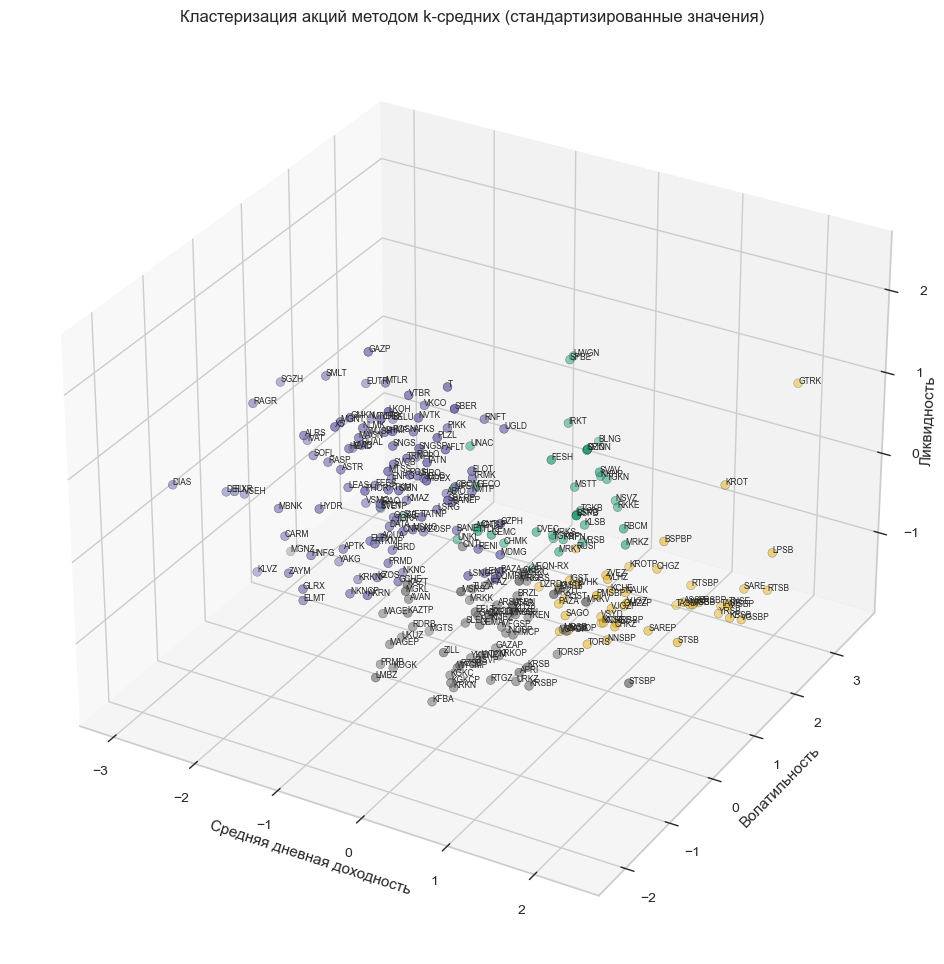

In [49]:
fig = plt.figure(figsize=(15, 12))

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],

    c=model_kmeans.labels_,
    cmap='Dark2',

    s=40,
    edgecolor='k'
)

for i, ticker in enumerate(history_agg['ticker']):

    ax.text(
        X[i, 0],
        X[i, 1],
        X[i, 2],

        ticker,
        fontsize=6
    )

ax.set_xlabel('Средняя дневная доходность')

ax.set_ylabel('Волатильность')

ax.set_zlabel(
    'Ликвидность',
    labelpad=-1
)

ax.set_title('Кластеризация акций методом k-средних (стандартизированные значения)')

plt.show()

Используя **метод главных компонент** можно визуализировать результат на двумерном графике.

In [50]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

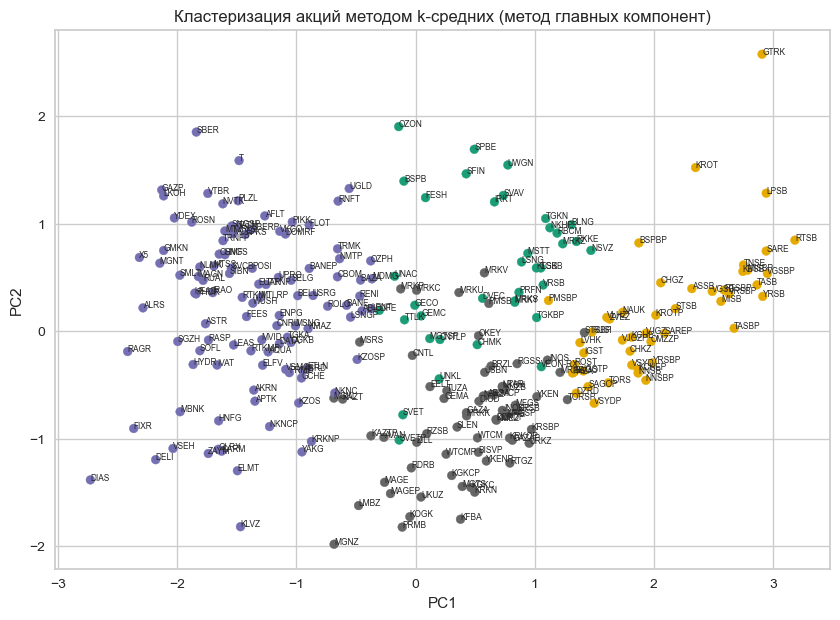

In [51]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],

    c=model_kmeans.labels_,
    cmap='Dark2',

    s=40
)

for i, ticker in enumerate(history_agg['ticker']):

    plt.text(
        X_pca[i, 0],
        X_pca[i, 1],

        ticker,
        fontsize=6
    )

plt.xlabel('PC1')

plt.ylabel('PC2')

plt.title(
    'Кластеризация акций методом k-средних (метод главных компонент)'
)

plt.show()

**Агломерацонный кластеринг**

Для построения модели агломерационного кластеринга необходимо определить количество кластеров.  
Согласно дендрограмме, оптимальное количество кластеров равно 4.

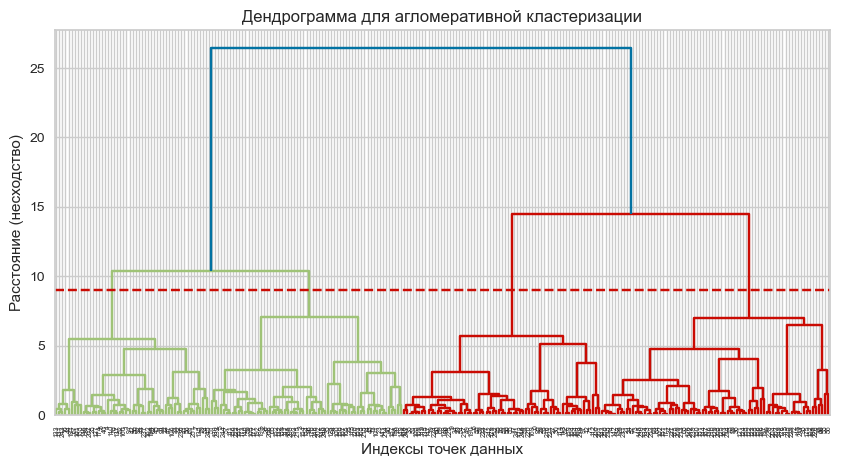

In [52]:
linked = sch.linkage(X, method='ward')

plt.figure(figsize=(10, 5))
sch.dendrogram(linked)

plt.title("Дендрограмма для агломеративной кластеризации")
plt.axhline(y=9, color='r', linestyle='--')

plt.xlabel("Индексы точек данных")
plt.ylabel("Расстояние (несходство)")

plt.show()

In [53]:
model_agg_cl = AgglomerativeClustering(n_clusters=4, linkage='ward')
model_agg_cl_labels = model_agg_cl.fit_predict(X)

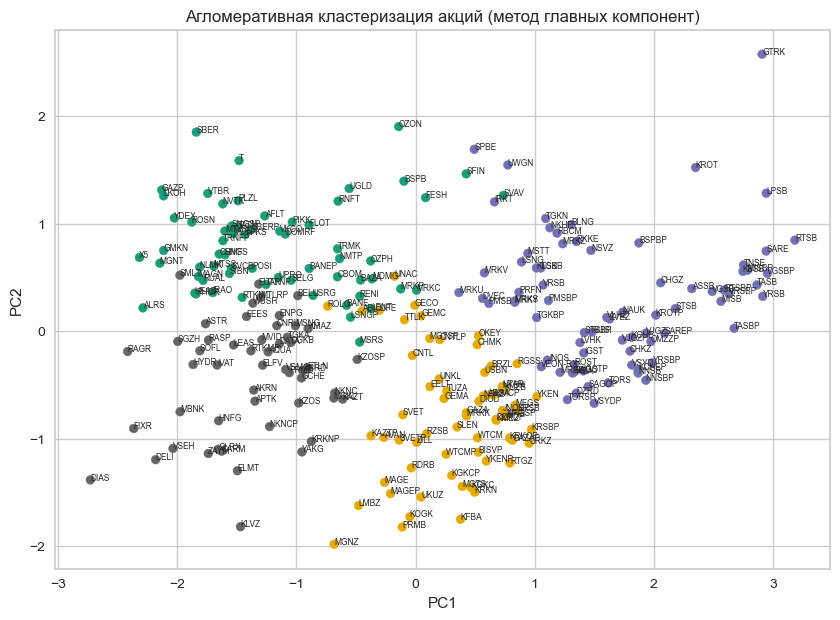

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],

    c=model_agg_cl.labels_,
    cmap='Dark2',

    s=40
)

for i, ticker in enumerate(history_agg['ticker']):

    plt.text(
        X_pca[i, 0],
        X_pca[i, 1],

        ticker,
        fontsize=6
    )

plt.xlabel('PC1')

plt.ylabel('PC2')

plt.title(
    'Агломеративная кластеризация акций (метод главных компонент)'
)

plt.show()

**DBSCAN**

Подобрать параметр eps, радиус соседства, можно с помощью графика расстояний до k-го ближайшего соседа. Оптимальное значение параметра определяется по точке резкого изменения наклона кривой (от 0,5 до 1).

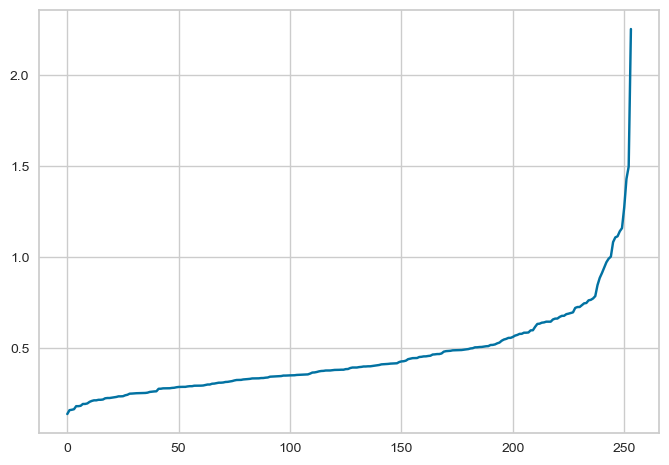

In [58]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors = neighbors.fit(X)
distances, indices = neighbors.kneighbors(X)
distances = distances[:,3]
distances.sort()

plt.plot(distances)
plt.show()

In [56]:
model_dbscan = DBSCAN(eps=0.5, min_samples=4) # при eps=0.7 модель классифицирует много выбросов, при eps=0.2 один кластер
model_dbscan_labels = model_dbscan.fit_predict(X)

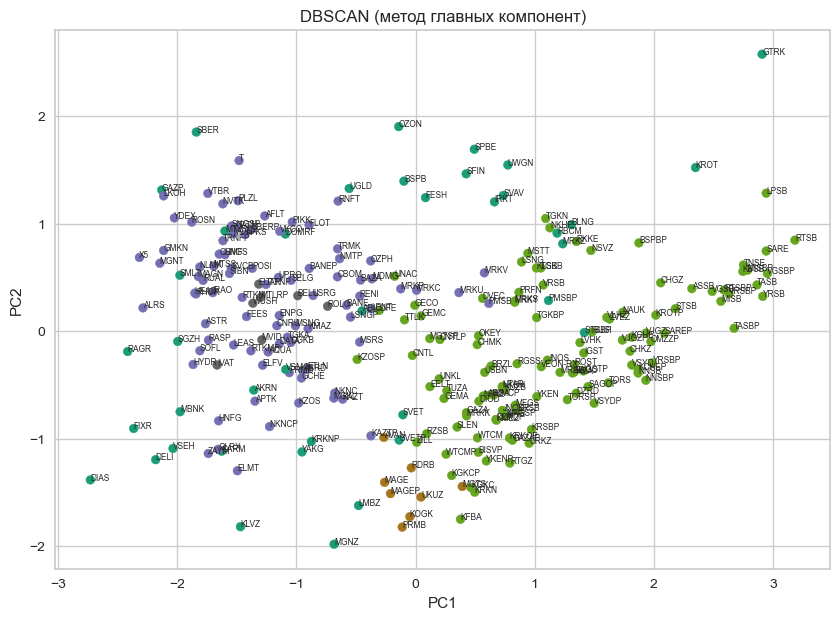

In [59]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],

    c=model_dbscan_labels,
    cmap='Dark2',

    s=40
)

for i, ticker in enumerate(history_agg['ticker']):

    plt.text(
        X_pca[i, 0],
        X_pca[i, 1],

        ticker,
        fontsize=6
    )

plt.xlabel('PC1')

plt.ylabel('PC2')

plt.title(
    'DBSCAN (метод главных компонент)'
)

plt.show()

## 6. Оценка качества моделей и их применимость к рассматриваемому набору данных.

Чтобы выбрать наиболее применимую к исследуемому набору данных модель, необходимо оценить их с помощью метрик:  

**Коэффициент силуэта** используется для оценки степени компактности кластеров и их отделимости друг от друга. Показывает, насколько объект близок к объектам собственного кластера и удалён от объектов соседних кластеров. Коэффициент принимает значение от -1 до 1. Чем выше оценка, тем 
лучше. 1 означает узкие кластеры, а О - перекрывающиеся кластеры. 

**Индекс Калинского-Харабаза** оценивает соотношение межкластерного и внутрикластерного разброса объектов. Показывает, насколько компактны объекты внутри кластеров и насколько хорошо кластеры отделены друг от друга. Высокие значения индекса свидетельствуют о формировании компактных и хорошо разделённых кластеров, тогда как низкие значения могут указывать на слабую структуру кластеризации и значительное пересечение групп объектов. Чем выше значение индекса Калинского–Харабаза, тем более качественным считается разбиение данных на кластеры.

**Индекс Дэвиса-Болдина**  оценивает степень сходства между кластерами на основе внутрикластерного разброса и расстояния между центрами кластеров.
Характеризует, насколько объекты внутри каждого кластера близки друг к другу и насколько хорошо различные кластеры отделены между собой. Для каждого кластера рассчитывается отношение внутрикластерного расстояния к расстоянию до наиболее похожего соседнего кластера, после чего значения усредняются по всем кластерам. Низкие значения метрики свидетельствуют о высокой компактности кластеров и хорошей разделимости групп объектов. Меньшие значения соответствуют более качественной кластеризации.

Характеристики модели **k-средних**.

In [60]:
s_score = silhouette_score(X, model_kmeans.labels_)

d_b_score = davies_bouldin_score(X, model_kmeans.labels_)

c_h_score = calinski_harabasz_score(X, model_kmeans.labels_)

print(f'Коэффициент силуэта: {s_score}')
print(f'Индекс Калинского-Харабаза: {c_h_score}')
print(f'Индекс Дэвиса-Болдина: {d_b_score}')

Коэффициент силуэта: 0.3390426854628448
Индекс Калинского-Харабаза: 155.420072329473
Индекс Дэвиса-Болдина: 1.0684507834568102


Характеристики модели **агломерационного клестеринга**.

In [61]:
s_score = silhouette_score(X, model_agg_cl.labels_)

d_b_score = davies_bouldin_score(X, model_agg_cl.labels_)

c_h_score = calinski_harabasz_score(X, model_agg_cl.labels_)

print(f'Коэффициент силуэта: {s_score}')
print(f'Индекс Калинского-Харабаза: {c_h_score}')
print(f'Индекс Дэвиса-Болдина: {d_b_score}')

Коэффициент силуэта: 0.2987915371036622
Индекс Калинского-Харабаза: 165.2110615918664
Индекс Дэвиса-Болдина: 1.1766438254053324


Характеристики модели **DBSCAN**.

In [62]:
s_score = silhouette_score(X, model_dbscan.labels_)

d_b_score = davies_bouldin_score(X, model_dbscan.labels_)

c_h_score = calinski_harabasz_score(X, model_dbscan.labels_)

print(f'Коэффициент силуэта: {s_score}')
print(f'Индекс Калинского-Харабаза: {c_h_score}')
print(f'Индекс Дэвиса-Болдина: {d_b_score}')

Коэффициент силуэта: 0.1189527256462654
Индекс Калинского-Харабаза: 55.17788783890408
Индекс Дэвиса-Болдина: 2.2125272526211455


Модель k-средних показала наилучший баланс между качеством разделения кластеров и их компактностью. Коэффициент силуэта оказался самым высоким среди рассмотренных моделей (0.339), что говорит о более чётком разделении объектов между кластерами. Индекс Дэвиса–Болдина имеет наименьшее значение (1.068), следовательно, кластеры являются более однородными и лучше отделены друг от друга. Несмотря на то что индекс Калинского–Харабаза немного уступает агломеративной модели, совокупность метрик показывает, что именно метод k-средних наиболее корректно описывает структуру исследуемых данных.  

Для данных фондового рынка данный метод хорошо подходит, поскольку признаки компаний после стандартизации формируют относительно компактные группы с близкими характеристиками доходности, волатильности и ликвидности.  

Метод k-средних обеспечивает наиболее сбалансированное разделение компаний на группы, формируя компактные и хорошо интерпретируемые кластеры по характеристикам доходности, волатильности и ликвидности.

## 7. Выбор наиболее релевантной модели и интерпретация результатов.

Размеченные с помощью метода k-средних данные сохранены в датафрейме "clusters".

In [64]:
clusters = pd.DataFrame(
    X,
    columns=[
        'mean_return',
        'volatility',
        'mean_value_log'
    ]
)

clusters['cluster'] = model_kmeans.labels_

In [65]:
clusters.head()

,mean_return,volatility,mean_value_log,cluster
0,-0.453500,0.082197,0.440928,1
1,-0.589997,-0.836581,0.158303,1
2,-0.456025,-0.608254,1.509688,1
3,0.014690,-0.787533,1.519108,1
4,-0.376259,-1.744843,0.129281,1


На основе средних значений стандартизированных признаков рассмотрим, как профили кластеров различаются между собой.

In [66]:
clusters_heatmap = clusters.groupby('cluster')[['mean_return', 'volatility', 'mean_value_log']].mean()

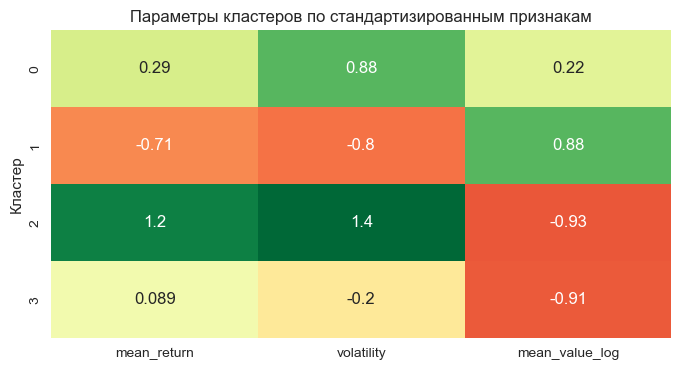

In [67]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    clusters_heatmap,
    annot=True,
    cmap='RdYlGn',
    center=0, 
    cbar=False
)

plt.title('Параметры кластеров по стандартизированным признакам')

plt.ylabel('Кластер')

plt.show()

Кластер 0: Доходность немного выше средней. Акции имеют повешенный, но не экстремальный риск. Ликвидность близка к среднерыночной.

Кластер 1: Доходность заметно ниже средней. Риск ниже среднего – низкая волатильность. Бумаги активно торгуются, имеют высокий спрос.

Кластер 2: Доходность очень высокая. Сильные колебания цен, высокий риск. Акции торгуются менее активно.

Кластер 3: Доходность близка к среднерыночной. Колебания цен чуть спокойнее рынка. Менее популярны у участников рынка.

Таким образом, можно интерпретировать следующие группы акций: 
- **Умеренно рискованные акции** (Кластер 0)
- **Защитные акции** (Кластер 1)
- **Спекулятивные акции** (Кластер 2)
- **Низколиквидные умеренные акции** (Кластер 3)

Полученные группы свидетельствуют о неоднородности структуры российского рынка акций и наличии выраженного разделения между крупными ликвидными бумагами и более рискованными акциями второго эшелона.

Дерево принятия решений, показывает приоритетность признаков, по которым модель принимала решение.

In [68]:
dtс = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dtс .fit(X, labels_kmeans)

DecisionTreeClassifier(max_depth=3, random_state=42)

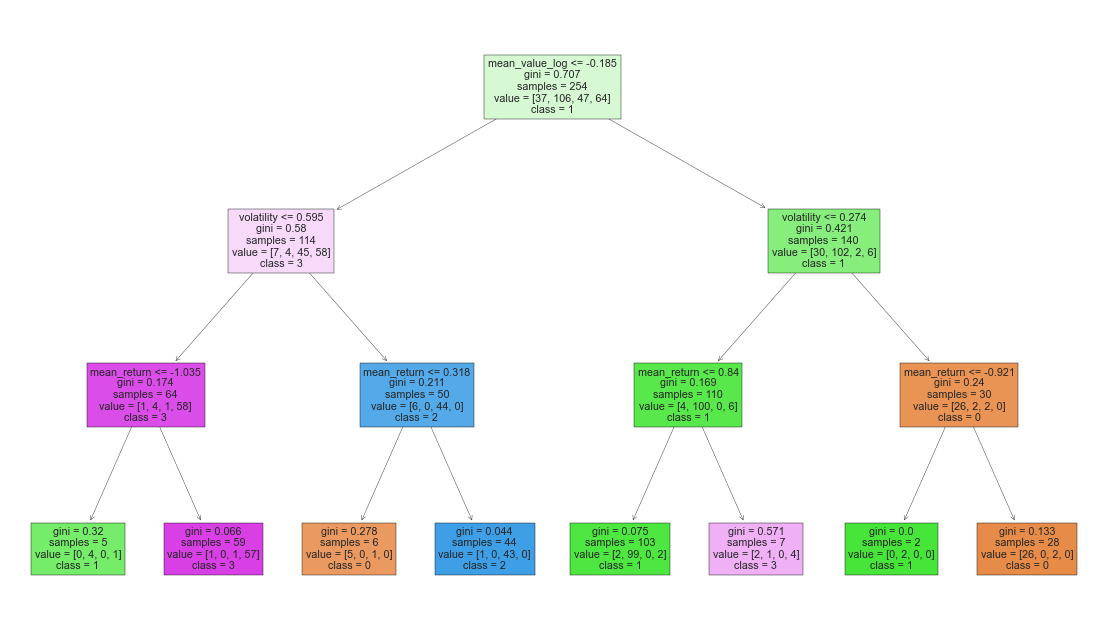

In [69]:
plt.figure(figsize=(14,8))

tree.plot_tree(
    dtс,
    feature_names=[
        'mean_return',
        'volatility',
        'mean_value_log'
    ],
    class_names=[
        '0',
        '1',
        '2',
        '3'
    ],
    filled=True
)

plt.show()

Рынок акций разделяется прежде всего по ликвидности. На следующем уровне разделения существенное влияние оказывает волатильность, тогда как доходность акций играет менее значимую роль при формировании кластеров.

**Сохраним полученный результат**

In [70]:
clusters_desc = history_agg.copy()

clusters_desc['cluster'] = model_kmeans.labels_
clusters_desc['pca1'] = X_pca[:, 0]
clusters_desc['pca2'] = X_pca[:, 1]

clusters_desc['return_scaled'] = X[:, 0]
clusters_desc['volatility_scaled'] = X[:, 1]
clusters_desc['liquidity_scaled'] = X[:, 2]

clusters_desc = clusters_desc.merge(dict, how='left', on='ticker')

clusters_desc.head()

,ticker,mean_return,volatility,mean_value,mean_value_log,cluster,pca1,pca2,return_scaled,volatility_scaled,liquidity_scaled,isin,sector,description
0,ABIO,0.000165,0.028179,8.737839e+07,18.285759,1,-0.449492,0.188654,-0.453500,0.082197,0.440928,RU000A0JNAB6,Медицина и биотехнологии,"Артген биотех - биотехнологическая компания, ц..."
1,ABRD,0.000041,0.020619,4.431064e+07,17.606735,1,-0.945020,-0.368104,-0.589997,-0.836581,0.158303,RU000A0JS5T7,Потребительский сектор,Завод шампанских вин «Абрау-Дюрсо» — крупнейши...
2,AFKS,0.000163,0.022498,1.139121e+09,20.853523,1,-1.431332,0.898799,-0.456025,-0.608254,1.509688,RU000A0DQZE3,Потребительский сектор,АФК «Система» является одной из самых крупных ...
3,AFLT,0.000593,0.021023,1.165196e+09,20.876155,1,-1.266128,1.071650,0.014690,-0.787533,1.519108,RU0009062285,Машиностроение и транспорт,"Группа «Аэрофлот» — авиакомпания, которая осущ..."
4,AKRN,0.000236,0.013145,4.132618e+07,17.537007,1,-1.358359,-0.547786,-0.376259,-1.744843,0.129281,RU0009028674,Сырьевая промышленность,"Группа ""Акрон"" входит в число ведущих мировых ..."


In [71]:
clusters_heatmap = clusters_heatmap.reset_index()
clusters_heatmap

,cluster,mean_return,volatility,mean_value_log
0,0,0.291396,0.878082,0.215087
1,1,-0.705438,-0.800188,0.884974
2,2,1.241079,1.385727,-0.928343
3,3,0.088502,-0.199973,-0.908333


In [72]:
clusters_sectors = clusters_desc.groupby(['sector', 'cluster'])['isin'].count().reset_index().rename(columns={'isin': 'count'})

clusters_sectors['id'] = range(1, len(clusters_sectors) + 1)
clusters_sectors = clusters_sectors[['id', 'sector', 'cluster', 'count']]

clusters_sectors.head()

,id,sector,cluster,count
0,1,Информационные технологии,0,4
1,2,Информационные технологии,1,12
2,3,Информационные технологии,3,1
3,4,Машиностроение и транспорт,0,7
4,5,Машиностроение и транспорт,1,5
